In [17]:
#1. Primera celda: importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("modelos", exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [37]:
#2. Cargar el dataset
df = pd.read_csv("glucosa_data.csv")
df.head()

,Edad,IMC,Actividad_Fisica,Nivel_Glucosa
0,42,13.466414,1,141.840332
1,67,23.455602,1,171.937432
2,71,25.765184,8,155.504232
3,48,24.079550,2,115.865231
4,35,24.426649,7,115.698730


In [38]:
#3. Revisar datos
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Edad              2000 non-null   int64  
 1   IMC               2000 non-null   float64
 2   Actividad_Fisica  2000 non-null   int64  
 3   Nivel_Glucosa     2000 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 62.6 KB


Edad                0
IMC                 0
Actividad_Fisica    0
Nivel_Glucosa       0
dtype: int64

In [39]:
#4. Separar variables
X = df[['Edad', 'IMC', 'Actividad_Fisica']]
y = df['Nivel_Glucosa']

In [40]:
#5. Dividir entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
#6. Entrenar modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
#7. Hacer predicciones
y_pred = modelo.predict(X_test)

y_pred

array([101.12396853, 106.06065638, 158.73686097, 134.63922789,
       155.83509761, 158.72163923, 100.84040917, 110.74139754,
       172.01252409, 149.13183985, 143.2733914 , 147.01545231,
       164.56697798, 170.74298231, 119.57186618, 140.33839747,
       181.72772067, 156.8092693 , 138.58224428, 163.60181516,
       174.87763814, 143.08957128, 130.41049349, 143.67891255,
       121.43728942, 144.20586643, 109.78410124, 149.12167023,
       103.64513335, 113.8156254 , 145.07090439, 141.97061309,
       115.90847855, 107.90404678, 137.52356411, 175.82808633,
       165.94656736, 139.23123164, 161.58647636,  96.66830971,
       154.51044109, 144.02586278, 117.83818584, 161.68477978,
       175.51880972, 185.53063051, 149.96185993, 105.66106966,
       155.98427007, 135.36371297, 146.05680772, 121.84536994,
       133.10148695, 135.56877671, 105.34384309, 138.42394501,
       139.25853304, 152.44640022, 144.17322952, 144.60152935,
       140.93392567, 116.58715527, 172.31046127, 142.18

In [43]:
#8. Evaluar modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 233.6930004508583
R²: 0.6813715865404839


In [44]:
#9. Ver coeficientes
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})

coeficientes

,Variable,Coeficiente
0,Edad,1.226590
1,IMC,0.933373
2,Actividad_Fisica,-2.085276


In [45]:
print("Intercepto:", modelo.intercept_)

Intercepto: 65.86086530452523


In [46]:
#10. Variable con mayor impacto
coeficientes['Impacto'] = coeficientes['Coeficiente'].abs()

coeficientes.sort_values(by='Impacto', ascending=False)

,Variable,Coeficiente,Impacto
2,Actividad_Fisica,-2.085276,2.085276
0,Edad,1.226590,1.226590
1,IMC,0.933373,0.933373


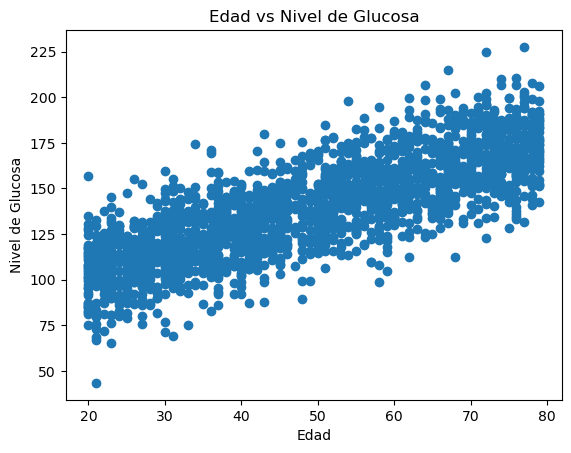

In [47]:
#11. Gráficas
plt.scatter(df['Edad'], df['Nivel_Glucosa'])
plt.xlabel("Edad")
plt.ylabel("Nivel de Glucosa")
plt.title("Edad vs Nivel de Glucosa")
plt.show()

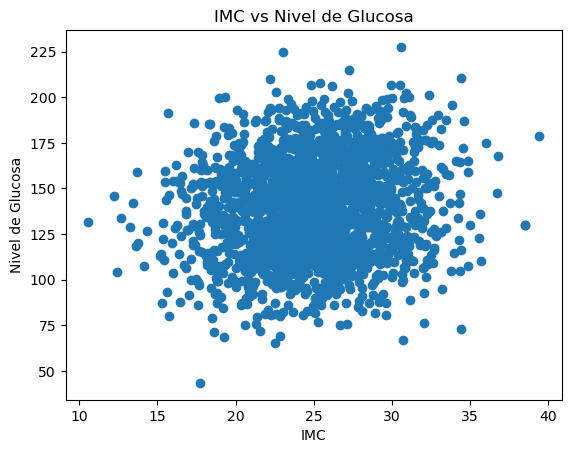

In [48]:
plt.scatter(df['IMC'], df['Nivel_Glucosa'])
plt.xlabel("IMC")
plt.ylabel("Nivel de Glucosa")
plt.title("IMC vs Nivel de Glucosa")
plt.show()

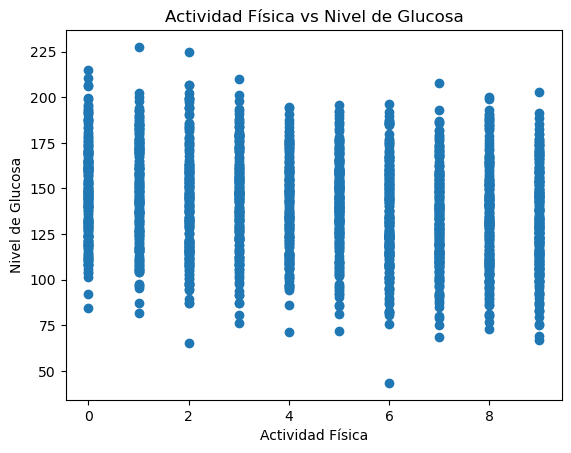

In [49]:
plt.scatter(df['Actividad_Fisica'], df['Nivel_Glucosa'])
plt.xlabel("Actividad Física")
plt.ylabel("Nivel de Glucosa")
plt.title("Actividad Física vs Nivel de Glucosa")
plt.show()

In [50]:
edad = float(input("Ingrese la edad: "))
imc = float(input("Ingrese el IMC: "))
actividad = float(input("Ingrese horas de actividad física: "))

nuevo_paciente = pd.DataFrame({
    'Edad': [edad],
    'IMC': [imc],
    'Actividad_Fisica': [actividad]
})

prediccion = modelo.predict(nuevo_paciente)

print("Nivel de glucosa estimado:", prediccion[0])

Ingrese la edad:  20
Ingrese el IMC:  4
Ingrese horas de actividad física:  2


Nivel de glucosa estimado: 89.95560553257053


In [51]:
joblib.dump(modelo, "modelos/modelo_glucosa.pkl")

['modelos/modelo_glucosa.pkl']

In [52]:
modelo_cargado = joblib.load("modelos/modelo_glucosa.pkl")

In [53]:
# ============================================================
# EXPORTAR MODELO Y VARIABLES EN UN SOLO ARCHIVO (GLUCOSA)
# ============================================================

import joblib
import os

# Crear carpeta si no existe
os.makedirs("modelos", exist_ok=True)

# Crear paquete del modelo
paquete_glucosa = {
    "modelo": modelo,  # tu modelo entrenado
    "variables": ["Edad", "IMC", "Actividad_Fisica"],
    "variable_objetivo": "Nivel_Glucosa",
    "nombre_modelo": "Predicción del nivel de glucosa"
}

# Guardar archivo
joblib.dump(paquete_glucosa, "modelos/paquete_modelo_glucosa.joblib")

print("Paquete del modelo exportado correctamente.")
print("Archivo creado: modelos/paquete_modelo_glucosa.joblib")

Paquete del modelo exportado correctamente.
Archivo creado: modelos/paquete_modelo_glucosa.joblib
